# **Pertby**
a first try, taken from [this](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html).


In [1]:
import warnings

import decoupler as dc
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

/scratch/michele.calabro/gears/VCC/vcc_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**REPLOGLE DATASET**: can be downlaoded from this package!!!

In [2]:
replogle_adata = pt.data.replogle_2022_k562_gwps()
replogle_adata

AnnData object with n_obs × n_vars = 1989578 × 8248
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells'

In [4]:
min_value = np.min(replogle_adata.X)
max_value = np.max(replogle_adata.X)
print("Min:", min_value, "Max:", max_value)

Min: 0.0 Max: 3426.0


In [10]:
replogle_adata.var_names

Index(['LINC01409', 'LINC01128', 'NOC2L', 'KLHL17', 'HES4', 'ISG15', 'SDF4',
       'B3GALT6', 'UBE2J2', 'ACAP3',
       ...
       'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB',
       'BX004987.1', 'AL354822.1', 'AC240274.1', 'AC004556.3'],
      dtype='object', name='gene_name', length=8248)

In [5]:
with open('echoes/gene_list.txt', 'r') as file:
    gene_list = [line.strip() for line in file.readlines()]

In [6]:
len(gene_list)

5127

In [8]:
mask = replogle_adata.var_names.isin(gene_list)
mask.shape

(8248,)

In [9]:
mask.sum()

np.int64(2385)

In [ ]:
with open('echoes/gene_list.txt', 'r') as file:
    gene_list = [line.strip() for line in file.readlines()]
sc.pp.filter_cells(replogle_adata, min_genes=200)
replogle_adata.raw = replogle_adata.copy() 
sc.pp.normalize_total(replogle_adata, target_sum = 1e4)
sc.pp.log1p(replogle_adata, base=2)
mask = adata.var_names.isin(gene_list)
adata = replogle_adata[:, mask].copy()
adata

***

In [2]:
adata = sc.read_h5ad('../data/vcc_data/adata_Training.h5ad')
adata

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

We remove perturbations with few samples

In [3]:
# filter genes to the ones with otherwise this takes forever
A = np.load('Patrick_networks/guanlab_stock_3.5k_directed.npz')
gene_names = A['gene_names']
gene_list = gene_names.tolist()
mask = adata.var_names.isin(gene_names)
adata = adata[:, mask].copy()
del A
adata

AnnData object with n_obs × n_vars = 221273 × 3406
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

In [4]:
adata.obs['target_gene'].value_counts()

target_gene
non-targeting    38176
TMSB4X            4760
PRCP              4331
TADA1             4035
HIRA              3407
                 ...  
BRD9                67
DNAJA3              65
OXA1L               63
RNF20               47
ATP6V0C             33
Name: count, Length: 151, dtype: int64

In [5]:
adata = adata[~adata.obs["target_gene"].isin(["BRD9", "DNAJA3", "OXA1L", "RNF20", "ATP6V0C"])]
adata

View of AnnData object with n_obs × n_vars = 220998 × 3406
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'gene_id'

In [6]:
adata.obs['target_gene'].unique()

['CHMP3', 'AKT2', 'SHPRH', 'TMSB4X', 'KLF10', ..., 'EPB41L2', 'ETV4', 'EPHB4', 'SUPT4H1', 'ATM']
Length: 146
Categories (146, object): ['ACAT2', 'ACVR1B', 'AKT2', 'ANTXR1', ..., 'ZNF562', 'ZNF593', 'ZNF714', 'non-targeting']

### **Pseudobulk**

To perform DE analysis on our sc dataset, we create pseudobulk samples by aggregating expression counts of cells within each group and sample of interest. 

This approach allows us to leverage statistical methods originally developed for bulk RNA-seq data, which is the **recommended best practice** to minimizing false positives in scRNA-seq DE analysis.

We create 1 pseudobulk sample per perturbation by summing up the gene counts within each subpopulation

In [7]:
adata.layers["counts"] = adata.X.copy()

In [ ]:
pdata = dc.pp.pseudobulk(
    adata,
    sample_col='target_gene',
    groups_col=None,
    layer='counts',
    mode='sum'
)

In [8]:
pdata = dc.pp.pseudobulk(
    adata,
    sample_col='batch',        # one row per sample x target_gene
    groups_col='target_gene',   # within each sample, group cells by perturbation
    layer='counts',
    mode='sum'
)

In [9]:
dc.pp.filter_samples(pdata, inplace=True) #QC: removes pseudobulks with  low total counts / Have too few expressed genes
pdata

AnnData object with n_obs × n_vars = 5788 × 3406
    obs: 'batch', 'target_gene', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_id'
    layers: 'psbulk_props'

### **Variation sources**
what is the main axis of variation that captures perturbation effects?

PCA analysis

In [10]:
pdata.layers["counts"] = pdata.X.copy()

sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.pp.pca(pdata)

In [11]:
# Return raw counts to X
dc.pp.swap_layer(pdata, "counts", inplace=True)

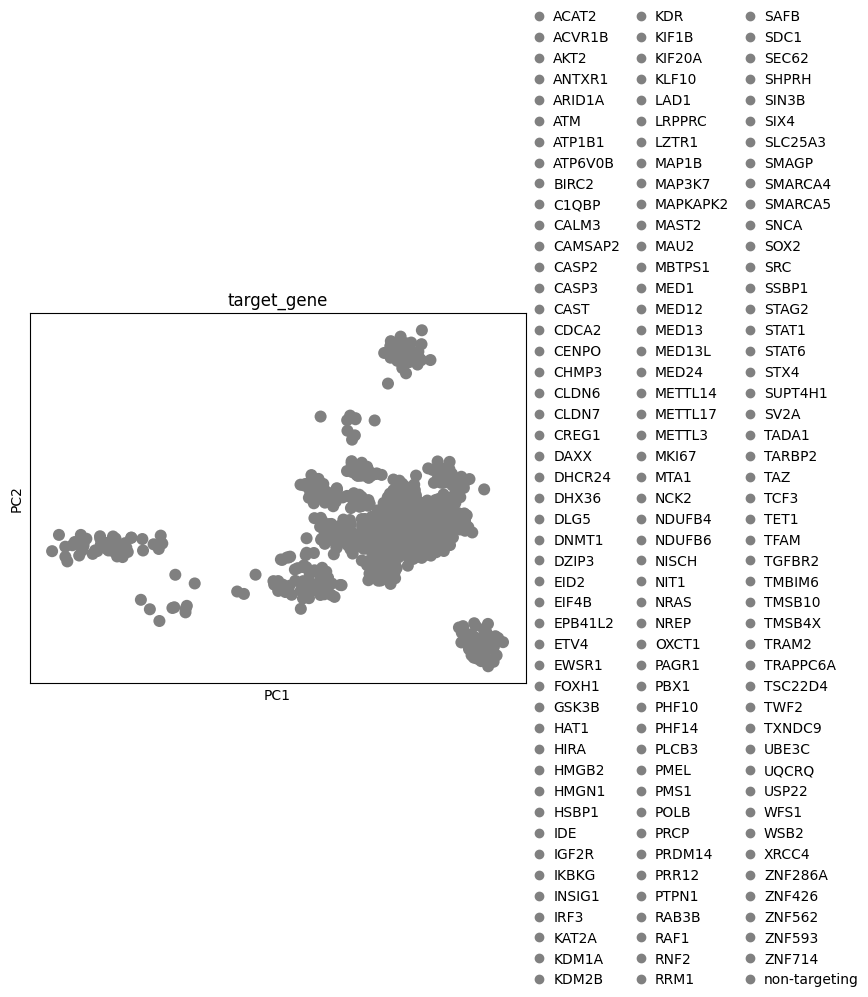

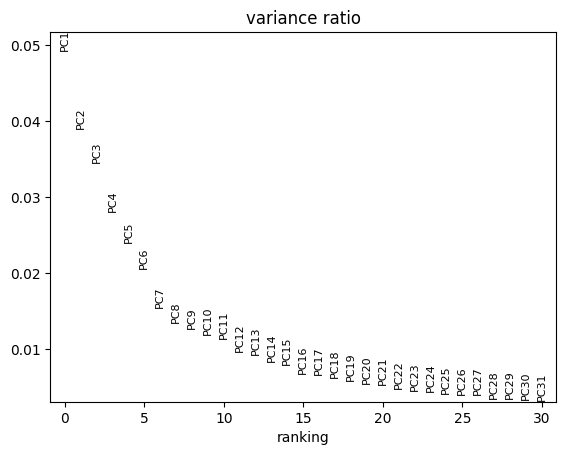

In [12]:
sc.pl.pca(pdata, color=["target_gene"], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

### **DE analysis using PyDESeq2**

In [13]:
pds2 = pt.tl.PyDESeq2(adata=pdata, design="~target_gene")
pds2.fit()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.78 seconds.

Fitting dispersions...
... done in 353.23 seconds.

Fitting dispersion trend curve...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 208.94 seconds.

Fitting LFCs...
... done in 204.39 seconds.

Calculating cook's distance...
... done in 1.73 seconds.

Replacing 846 outlier genes.

Fitting dispersions...
... done in 70.51 seconds.

Fitting MAP dispersions...
... done in 40.81 seconds.

Fitting LFCs...
... done in 54.68 seconds.



In [14]:
import pickle

with open('results/pertpy_degs.pkl', 'wb') as f:
    pickle.dump(pds2, f)

In [5]:
import pickle

with open('results/pertpy_degs.pkl', 'rb') as file:
    pds2 = pickle.load(file)

In [14]:
res_df = pds2.test_contrasts(pds2.contrast(column="target_gene", baseline="non-targeting", group_to_compare="SHPRH"))
res_df.head(10)


Running Wald tests...


... done in 7539.07 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.]
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ISG15     41.306788        0.061657  0.268928  0.229271  0.818658  0.986732
AGRN     178.579403        0.311443  0.124815  2.495241  0.012587  0.493191
MXRA8     23.248615       -0.569341  0.433400 -1.313661  0.188960  0.978815
CCNL2    352.287395        0.022920  0.107216  0.213773  0.830724  0

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,VIM,572.295303,-3.437978,0.297928,-11.539643,8.327018e-31,2.835350e-27,None
1,KCNK5,134.823538,-3.752606,0.514449,-7.294413,2.999637e-13,5.106882e-10,None
2,GSN,102.138885,-4.350636,0.724722,-6.003184,1.934855e-09,2.196060e-06,None
3,SHPRH,92.167987,-4.190773,0.723336,-5.793674,6.886306e-09,5.861968e-06,None
4,CLMP,79.965941,-1.680555,0.329866,-5.094660,3.493668e-07,2.024651e-04,None
5,COL6A1,265.716296,-0.759265,0.149148,-5.090688,3.567667e-07,2.024651e-04,None
6,ACTC1,73.039876,1.002990,0.225200,4.453778,8.437237e-06,4.104113e-03,None
7,COL5A2,22.879033,1.145891,0.263797,4.343828,1.400214e-05,5.959659e-03,None
8,SOGA1,79.595169,0.671426,0.159699,4.204333,2.618536e-05,9.693635e-03,None
9,COL6A2,260.619188,-0.607605,0.145173,-4.185381,2.846883e-05,9.693635e-03,None


NaNs encountered, dropping rows with NaNs


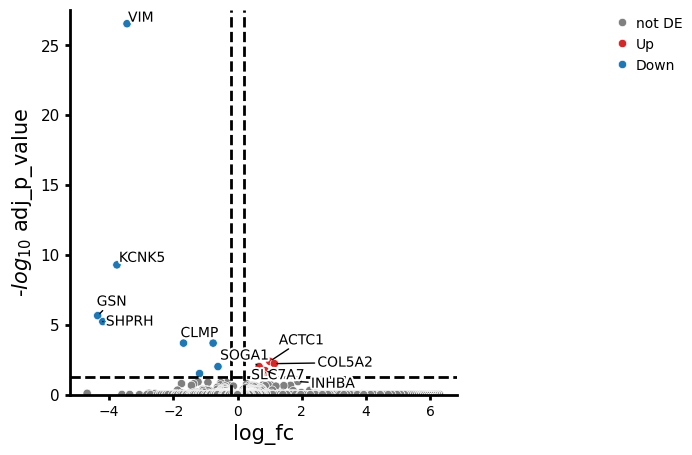

In [15]:
pds2.plot_volcano(res_df, log2fc_thresh=0.2)


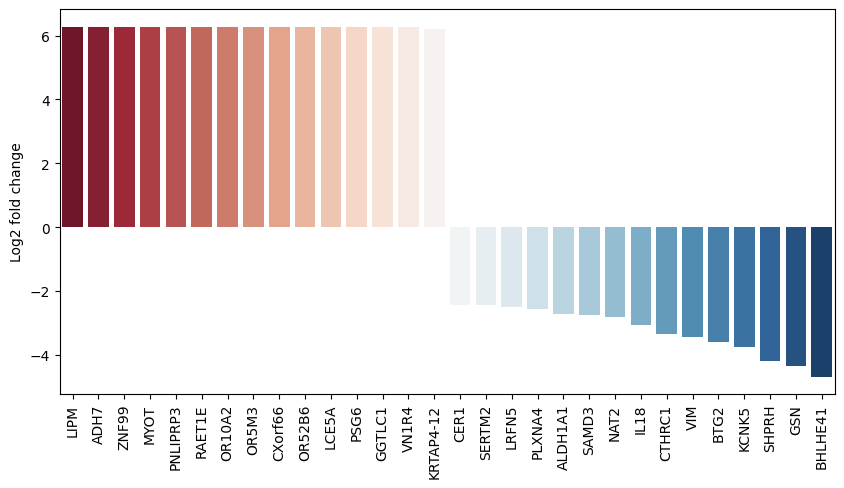

In [16]:
pds2.plot_fold_change(res_df, n_top_vars=15)
